In [2]:
!ls

'Salary Data .csv'   sample_data


Dataset Loading:
The salary dataset was loaded into Python using the Pandas library. Initial exploration was performed to understand the structure, number of records, data types, and available features.

In [6]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [8]:
# LOAD DATASET
df = pd.read_csv("Salary Data .csv")

In [10]:
# UNDERSTAND DATASET
print("="*50)
print("DATASET INFORMATION")
print("="*50)
print("\nShape of Dataset:")
print(df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 5 Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

DATASET INFORMATION

Shape of Dataset:
(375, 6)

Columns:
Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

First 5 Rows:
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1  

Missing Value Handling :
The dataset was checked for missing values using the isnull() function.
Categorical columns were filled with the most frequently occurring value (Mode).
Numerical columns were filled with the Median value.
This approach preserves the dataset size and prevents errors during model training.

In [11]:
# HANDLE MISSING VALUES
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


Duplicate Record Removal:
Duplicate rows were identified using the duplicated() function and removed using drop_duplicates().
This ensures that repeated records do not bias the machine learning models.

In [12]:
# REMOVE DUPLICATES
print("\nDuplicate Records Before:")
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate Records After:")
print(df.duplicated().sum())


Duplicate Records Before:
50
Duplicate Records After:
0


Outlier Detection and Removal:
Outliers were detected using the Interquartile Range (IQR) method.
Process:
Calculate Q1 (25th percentile)
Calculate Q3 (75th percentile)
Compute IQR = Q3 − Q1
Define lower and upper bounds
Remove observations outside these bounds
Removing outliers improves model accuracy and reduces the influence of extreme values.

In [13]:
# OUTLIER DETECTION & REMOVAL
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]
print("\nShape After Outlier Removal:")
print(df.shape)


Shape After Outlier Removal:
(325, 6)


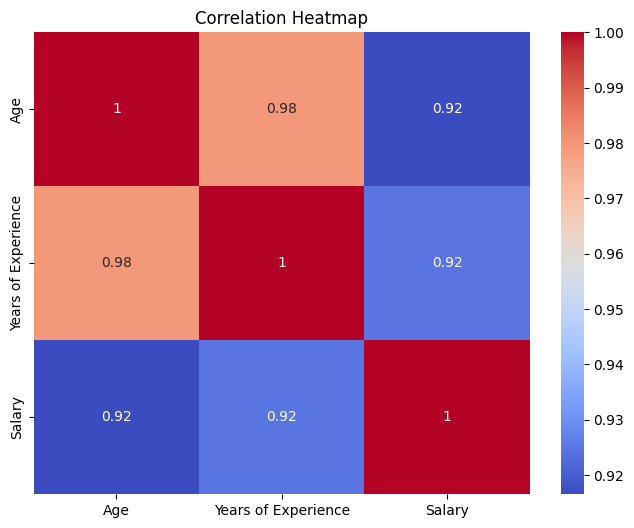

In [29]:
# CORRELATION HEATMAP
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Feature and Target Separation:
The target variable selected for prediction was: Salary
All remaining columns were used as input features.

In [16]:
# FEATURES & TARGET
target_column = "Salary"
X = df.drop(target_column, axis=1)
y = df[target_column]

In [17]:
# IDENTIFY COLUMN TYPES
categorical_cols = X.select_dtypes(
    include="object"
).columns
numerical_cols = X.select_dtypes(
    exclude="object"
).columns

Categorical Data Encoding:
Machine learning algorithms require numerical inputs.
Categorical features such as:
Gender
Education Level
Job Title
were converted into numerical format using One-Hot Encoding.

Feature Scaling:
Numerical features were standardized using StandardScaler.
This transforms the data to have:
Mean = 0
Standard Deviation = 1
Feature scaling improves model performance and training efficiency.

In [18]:
#Categorical Data Encoding
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

Train-Test Split:
The dataset was divided into:
80% Training Data
20% Testing Data
This allows the model to learn from one portion of the data and be evaluated on unseen data.

In [19]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [20]:
# MODELS
models = {
    "Linear Regression":
        LinearRegression(),
    "Decision Tree Regressor":
        DecisionTreeRegressor(
            random_state=42
        ),
    "Random Forest Regressor":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )
}

In [21]:
# TRAINING & EVALUATION
results = []
best_r2 = -999
best_pipeline = None
best_model_name = ""
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(
        y_test,
        y_pred
          )
    mse = mean_squared_error(
        y_test,
        y_pred
    )
    rmse = np.sqrt(mse)
    r2 = r2_score(
        y_test,
        y_pred
    )
    results.append([
        name,
        round(mae,2),
        round(mse,2),
        round(rmse,2),
        round(r2,4)
 ])

    if r2 > best_r2:
        best_r2 = r2
        best_pipeline = pipeline
        best_model_name = name

In [22]:
# RESULTS TABLE
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)
print("\n")
print("="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)
print(results_df)



MODEL EVALUATION RESULTS
                     Model       MAE           MSE      RMSE  R2 Score
0        Linear Regression   9890.55  1.840399e+08  13566.13    0.9194
1  Decision Tree Regressor  12000.00  3.561538e+08  18872.04    0.8440
2  Random Forest Regressor   8497.59  1.576172e+08  12554.57    0.9310


In [24]:
# BEST MODEL
print("\nBest Model:")
print(best_model_name)


Best Model:
Random Forest Regressor


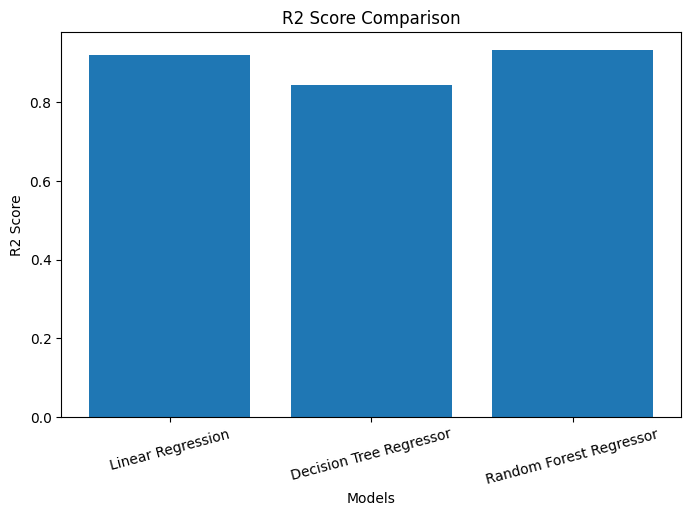

In [25]:
# R2 SCORE COMPARISON GRAPH
plt.figure(figsize=(8,5))
plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.show()

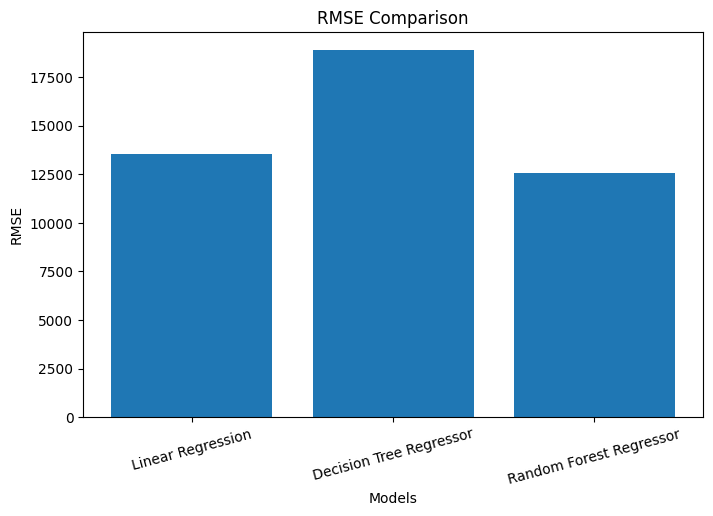

In [26]:
# RMSE COMPARISON GRAPH
plt.figure(figsize=(8,5))
plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)
plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

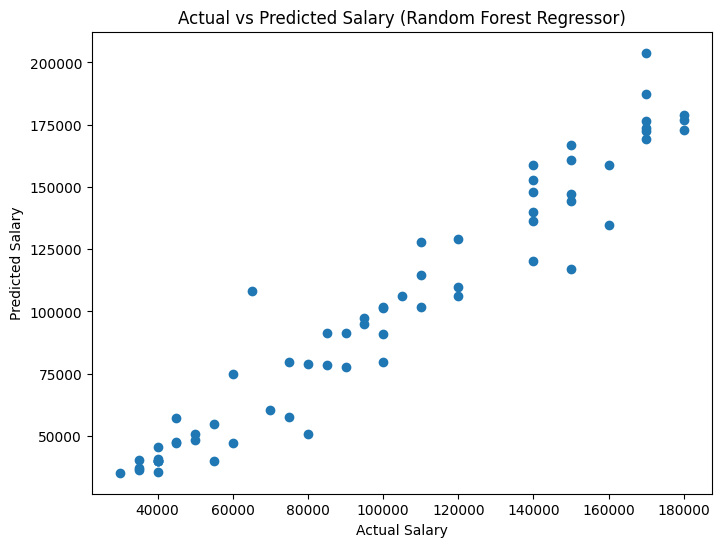

In [27]:
# ACTUAL VS PREDICTED GRAPH
y_pred_best = best_pipeline.predict(X_test)
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred_best
)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title(
    f"Actual vs Predicted Salary ({best_model_name})"
    )
plt.show()

In [28]:
# SAVE CLEANED DATASET
df.to_csv(
    "Salary_Cleaned_Dataset.csv",
    index=False
)
print("\nCleaned Dataset Saved Successfully!")


Cleaned Dataset Saved Successfully!
